# Hack4Her - Churn Hunters

### Equipo: Las Tortugas Hackatecas

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
clientes=pd.read_csv('/content/gdrive/MyDrive/ChurnHunters_Hack4Her26/Clientes.csv')
coolers=pd.read_csv('/content/gdrive/MyDrive/ChurnHunters_Hack4Her26/Coolers.csv')
churntest=pd.read_csv('/content/gdrive/MyDrive/ChurnHunters_Hack4Her26/sales_churn_test.csv')
churntrain=pd.read_csv('/content/gdrive/MyDrive/ChurnHunters_Hack4Her26/sales_churn_train.csv')

In [ ]:
clientes.shape

(371727, 4)

In [ ]:
churntrain.shape

(5030534, 5)

In [ ]:
coolers.shape

(4636676, 4)

In [ ]:
churntest.shape

(199923, 4)

In [ ]:
clientes['comercial_subchannel_d'].value_counts()

,count
comercial_subchannel_d,
Hogares,128988
Abarrotes y bodegas,86562
Kiosco,75969
Licorería,31498
Verdulería,12236
Farmacia,6893
Tiendas de carne/pollo/pescado,6885
Tienda orgánica,6148
Tortillería,6104


In [ ]:
clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 371727 entries, 0 to 371726
Data columns (total 4 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   customer_id             371727 non-null  object
 1   territory_d             371727 non-null  object
 2   comercial_subchannel_d  371727 non-null  object
 3   rtm_customer_size_d     356289 non-null  object
dtypes: object(4)
memory usage: 11.3+ MB


In [ ]:
faltantes1 = clientes.isnull().sum()
porcentaje_faltantes = (faltantes1 / len(clientes)) * 100

resumen_faltantes = pd.DataFrame({
    "Faltantes": faltantes1,
    "Porcentaje": porcentaje_faltantes
})

print(resumen_faltantes.sort_values(by="Porcentaje", ascending=False))

                        Faltantes  Porcentaje
rtm_customer_size_d         15438    4.153048
customer_id                     0    0.000000
territory_d                     0    0.000000
comercial_subchannel_d          0    0.000000


In [ ]:
faltantes2 = coolers.isnull().sum()
porcentaje_faltantes = (faltantes2 / len(coolers)) * 100

resumen_faltantes = pd.DataFrame({
    "Faltantes": faltantes2,
    "Porcentaje": porcentaje_faltantes
})

print(resumen_faltantes.sort_values(by="Porcentaje", ascending=False))

             Faltantes  Porcentaje
customer_id          0         0.0
calmonth             0         0.0
num_coolers          0         0.0
num_doors            0         0.0


In [ ]:
faltantes3 = churntrain.isnull().sum()
porcentaje_faltantes = (faltantes3 / len(churntrain)) * 100

resumen_faltantes = pd.DataFrame({
    "Faltantes": faltantes3,
    "Porcentaje": porcentaje_faltantes
})

print(resumen_faltantes.sort_values(by="Porcentaje", ascending=False))

                   Faltantes  Porcentaje
customer_id                0         0.0
calmonth                   0         0.0
num_transacciones          0         0.0
uni_boxes_sold_m           0         0.0
target                     0         0.0


In [ ]:
(clientes['rtm_customer_size_d'].isnull().sum()/len(clientes))*100

np.float64(4.153047801208952)

In [ ]:
# eliminando registros nulos, regresentan el 4% de los datos
clientes.dropna(inplace=True)

In [ ]:
churntrain['customer_id'].duplicated().sum()

np.int64(4788729)

In [ ]:
duplicados = churntrain.duplicated().sum()
print("\nNúmero de duplicados exactos:", duplicados)


Número de duplicados exactos: 0


In [ ]:
clientes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 356289 entries, 0 to 371676
Data columns (total 4 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   customer_id             356289 non-null  object
 1   territory_d             356289 non-null  object
 2   comercial_subchannel_d  356289 non-null  object
 3   rtm_customer_size_d     356289 non-null  object
dtypes: object(4)
memory usage: 13.6+ MB


valores faltantes en rtm_customer_size_d

In [ ]:
clientes.dropna(axis=1,inplace=True)
clientes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 356289 entries, 0 to 371676
Data columns (total 4 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   customer_id             356289 non-null  object
 1   territory_d             356289 non-null  object
 2   comercial_subchannel_d  356289 non-null  object
 3   rtm_customer_size_d     356289 non-null  object
dtypes: object(4)
memory usage: 13.6+ MB


### Unificar dataset

In [ ]:
merged_churntrain_coolers = pd.merge(churntrain, coolers, on=['customer_id', 'calmonth'], how='left')
final_merge=pd.merge(merged_churntrain_coolers,clientes,on='customer_id',how='left')
final_merge.head()

,customer_id,calmonth,num_transacciones,uni_boxes_sold_m,target,num_coolers,num_doors,territory_d,comercial_subchannel_d,rtm_customer_size_d
0,d72f5c4b018e0d32afb78d1db0eeaa2a85ea2107058284...,202410,29,65.166068,0,1.0,1.0,Saltillo,Hogares,Mini
1,d72f5c4b018e0d32afb78d1db0eeaa2a85ea2107058284...,202411,25,56.640400,0,1.0,1.0,Saltillo,Hogares,Mini
2,d72f5c4b018e0d32afb78d1db0eeaa2a85ea2107058284...,202412,10,21.486900,0,1.0,1.0,Saltillo,Hogares,Mini
3,d72f5c4b018e0d32afb78d1db0eeaa2a85ea2107058284...,202501,11,21.698000,0,1.0,1.0,Saltillo,Hogares,Mini
4,d72f5c4b018e0d32afb78d1db0eeaa2a85ea2107058284...,202502,17,33.709400,0,1.0,1.0,Saltillo,Hogares,Mini


In [ ]:
final_merge.shape

(5032039, 10)

In [ ]:
final_merge['customer_id'].value_counts()

,count
customer_id,
fcc8c23541b573aa49feade60a7c4b047d4a81ebe2bb494e60eb24e7,45
4c8af70b1a9856a6ef407bac1859fc62c9de6ebbbf0b0442ae6a4028,45
701f8ef1417a8b4f397f449ec376b72a5cd9d457ea42d5f75adc7974,45
742964cba0fe277ffd12c7dac6eb9c2b5d9e86747daab49f42f72d40,45
4526c63d767d804f956325fffde365e8ceda6c13b586304a64a1f4be,45
...,...
90952650d3bc2574444c3b1e323167c0e6d07f4b63f3dbeb3e2f758a,1
87c3a4c3c7c8297029ddff6ac18aaa873a7e5d2f7bdb254ac6cd4ac1,1
5fe4a491441d4a09eb2f081fbfdf02f2c3d3b87f2b1033623d6331a6,1


## Territorio

In [ ]:
final_merge['territory_d'].value_counts()

,count
territory_d,
Guadalajara,619524
Monterrey,518571
Jalisco,450798
Aguascalientes,321956
San Luis Potosi,315718
Zacatecas,305387
Comarca Lagunera,265995
Culiacan,242344
Durango,181470


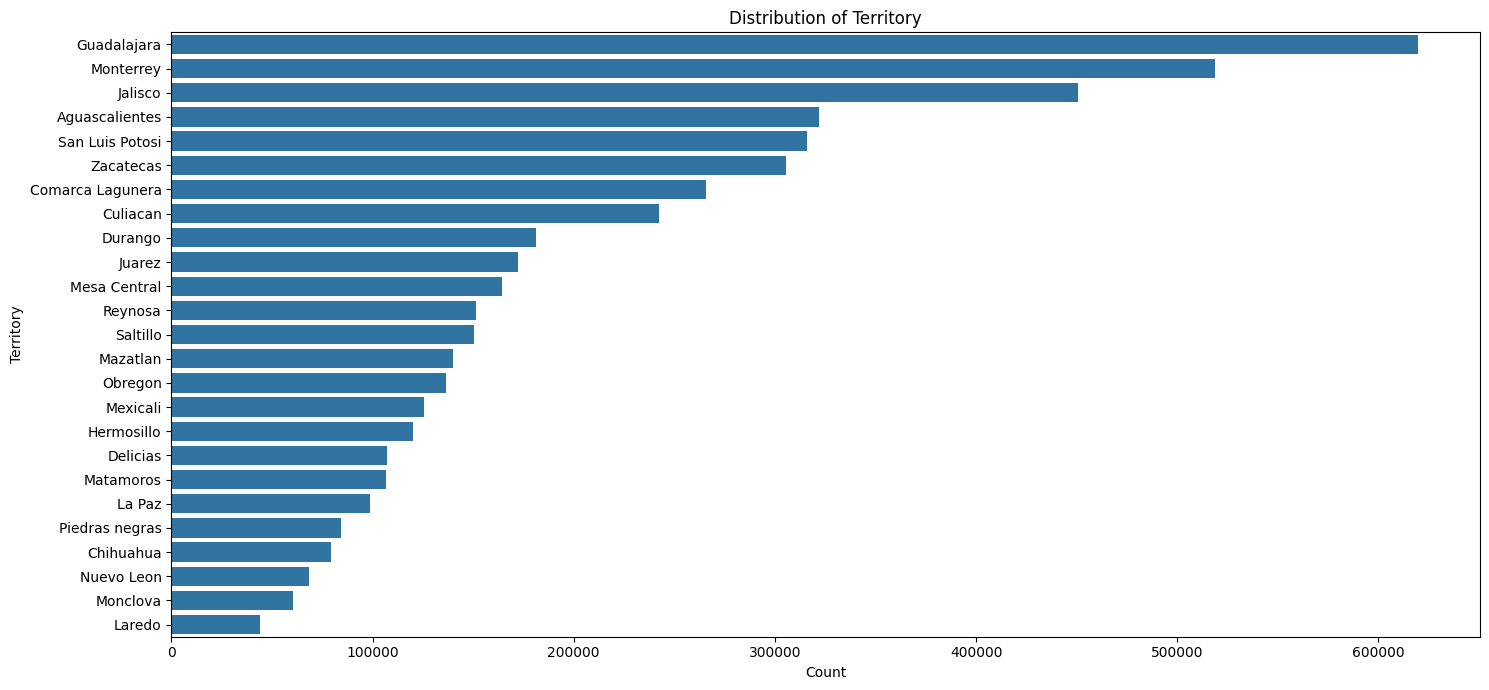

In [ ]:
plt.figure(figsize=(15, 7))
sns.countplot(data=final_merge, y='territory_d', order=final_merge['territory_d'].value_counts().index)
plt.title('Distribution of Territory')
plt.xlabel('Count')
plt.ylabel('Territory')
plt.tight_layout()
plt.show()

In [ ]:
estado_churn = (
    final_merge
    .groupby("territory_d")["target"]
    .mean()
    .sort_values(ascending=False)
)

Text(0, 0.5, 'Tasa de churn')

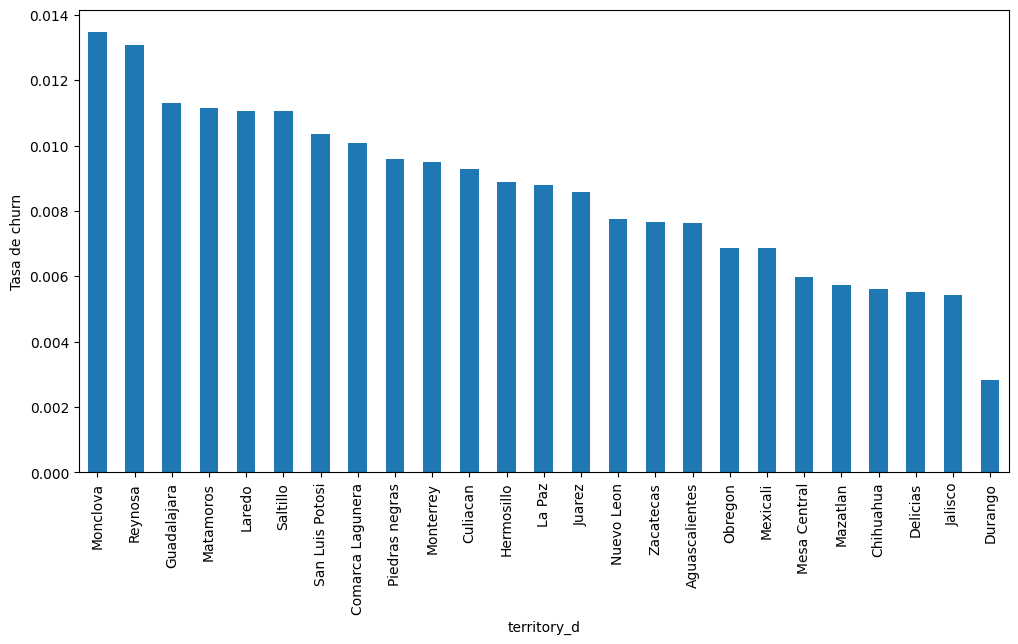

In [ ]:
plt.figure(figsize=(12,6))
estado_churn.plot(kind="bar")
plt.ylabel("Tasa de churn")

In [ ]:
perdidos_estado = (
    final_merge
    .groupby("territory_d")["target"]
    .sum()
    .sort_values(ascending=False)
)

<Axes: ylabel='territory_d'>

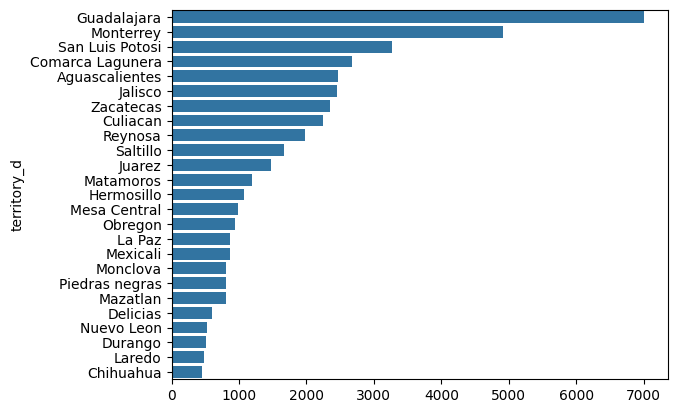

In [ ]:
sns.barplot(
    x=perdidos_estado.values,
    y=perdidos_estado.index
)

In [ ]:
pivot = pd.pivot_table(
    final_merge,
    values="target",
    index="territory_d",
    columns="rtm_customer_size_d",
    aggfunc="mean"
)

<Axes: xlabel='rtm_customer_size_d', ylabel='territory_d'>

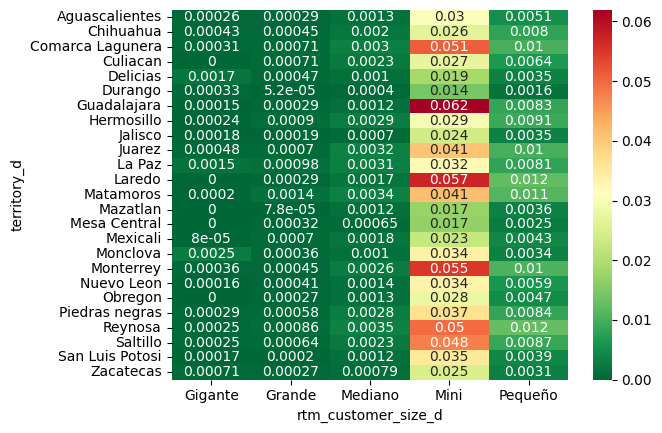

In [ ]:
sns.heatmap(
    pivot,
    annot=True,
    cmap="RdYlGn_r"
)

In [ ]:
estado_enfriadores = (
    final_merge
    .groupby("territory_d")
    .agg({
        "num_coolers":"mean",
        "target":"mean"
    })
)

<Axes: xlabel='num_coolers', ylabel='target'>

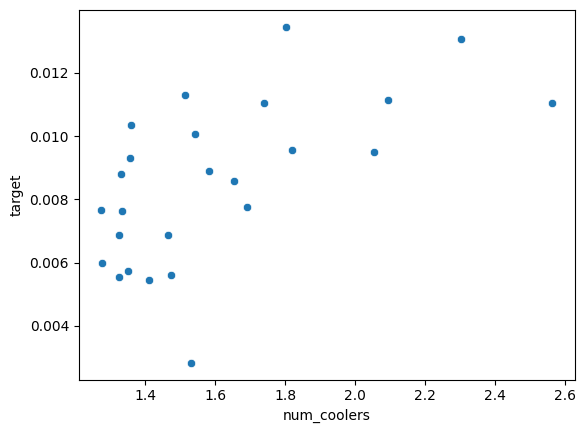

In [ ]:
sns.scatterplot(
    data=estado_enfriadores,
    x="num_coolers",
    y="target"
)

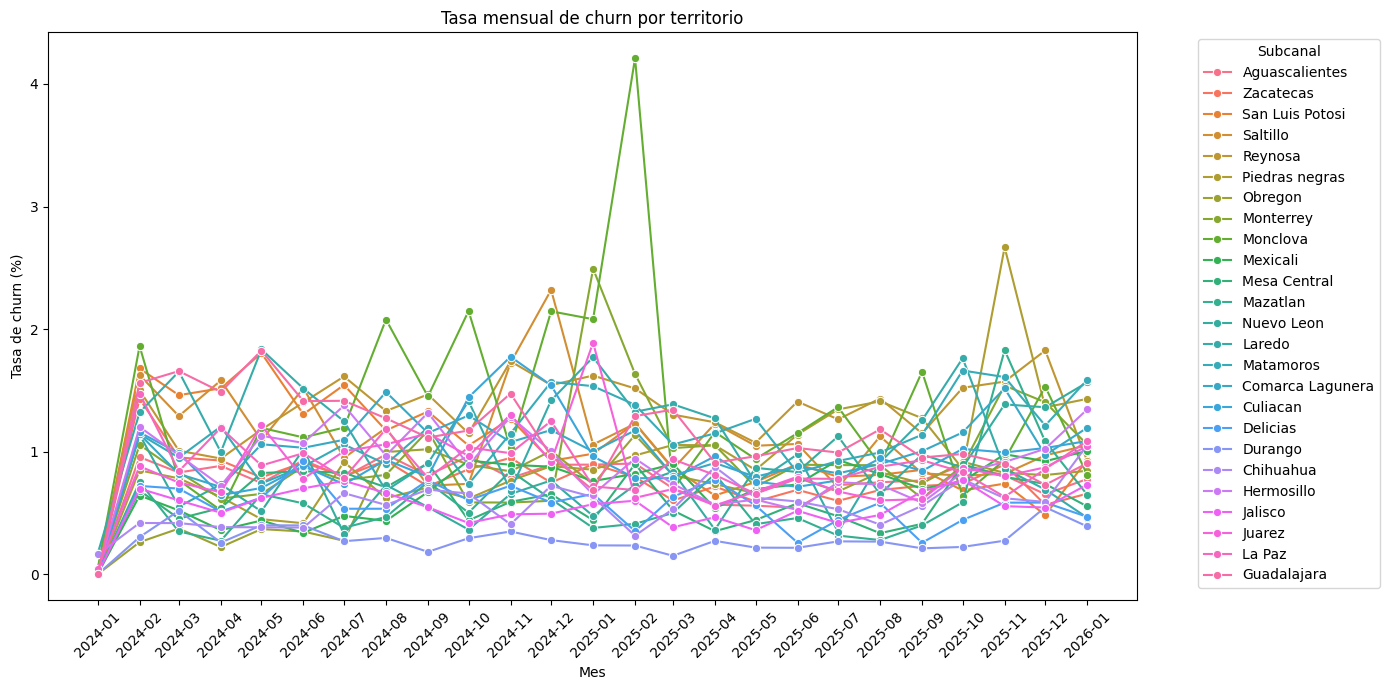

In [ ]:
final_merge["calmonth_dt"] = pd.to_datetime(
    final_merge["calmonth"].astype(str),
    format="%Y%m"
)

# 2. Tasa de churn por mes y subcanal
churn_mes = (
    final_merge
    .groupby(["calmonth_dt", "territory_d"])["target"]
    .mean()
    .mul(100)
    .reset_index()
)

# 3. Ordenar meses
churn_mes = churn_mes.sort_values("calmonth_dt")

# 4. Gráfica temporal corregida
plt.figure(figsize=(14,7))

sns.lineplot(
    data=churn_mes,
    x="calmonth_dt",
    y="target",
    hue="territory_d",
    marker="o"
)

plt.title("Tasa mensual de churn por territorio")
plt.xlabel("Mes")
plt.ylabel("Tasa de churn (%)")
plt.xticks(
    churn_mes["calmonth_dt"].drop_duplicates(),
    churn_mes["calmonth_dt"].dt.strftime("%Y-%m").drop_duplicates(),
    rotation=45
)
plt.legend(title="Subcanal", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import chi2_contingency

tabla = pd.crosstab(
    final_merge["territory_d"],
    final_merge["target"]
)

chi2,p,dof,expected = chi2_contingency(tabla)

print(p)

0.0


## SUBCANAL

Text(0, 0.5, 'Clientes')

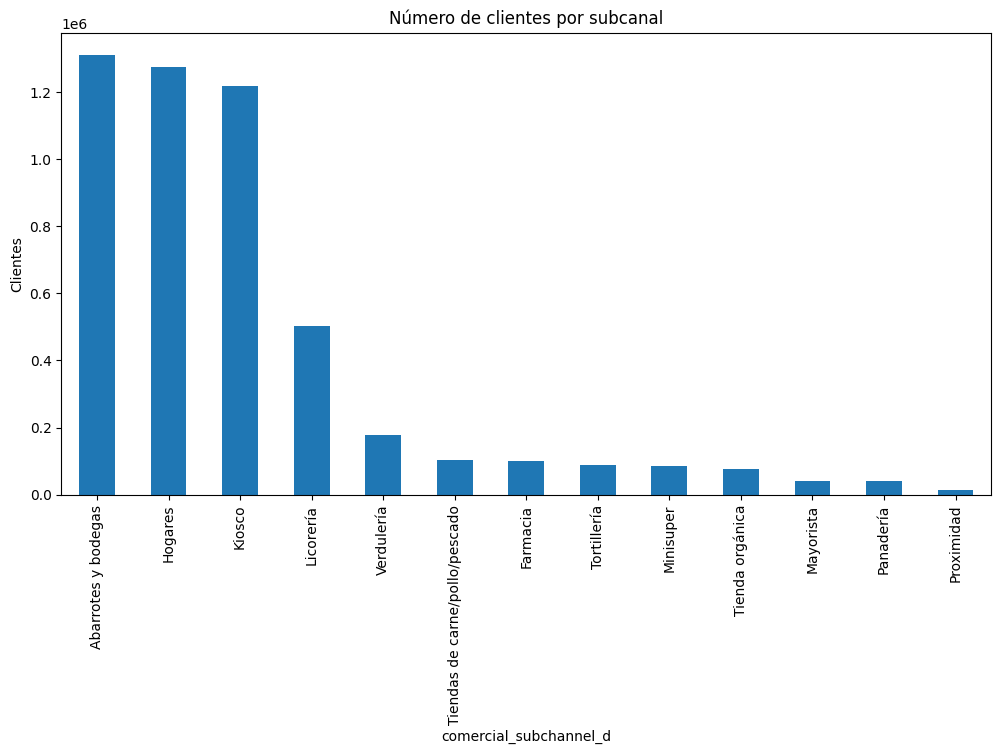

In [ ]:
plt.figure(figsize=(12,6))

final_merge["comercial_subchannel_d"].value_counts().plot(
    kind="bar"
)

plt.title("Número de clientes por subcanal")
plt.ylabel("Clientes")

In [ ]:
final_merge["comercial_subchannel_d"].value_counts(normalize=True)*100

,proportion
comercial_subchannel_d,
Abarrotes y bodegas,26.074063
Hogares,25.335972
Kiosco,24.214439
Licorería,10.008527
Verdulería,3.535764
Tiendas de carne/pollo/pescado,2.033192
Farmacia,1.977687
Tortillería,1.723556
Minisuper,1.698318


In [ ]:
subchannel_churn = (
    final_merge
    .groupby("comercial_subchannel_d")["target"]
    .mean()
    .sort_values(ascending=False)
)

Text(0, 0.5, 'Subcanal')

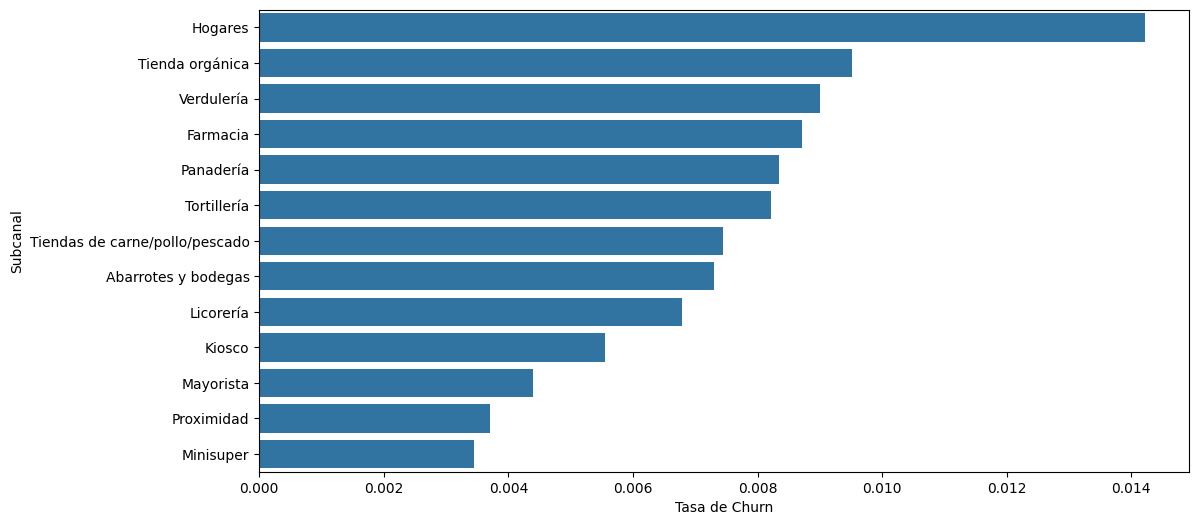

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=subchannel_churn.values,
    y=subchannel_churn.index
)

plt.xlabel("Tasa de Churn")
plt.ylabel("Subcanal")

(0.0, 10.0)

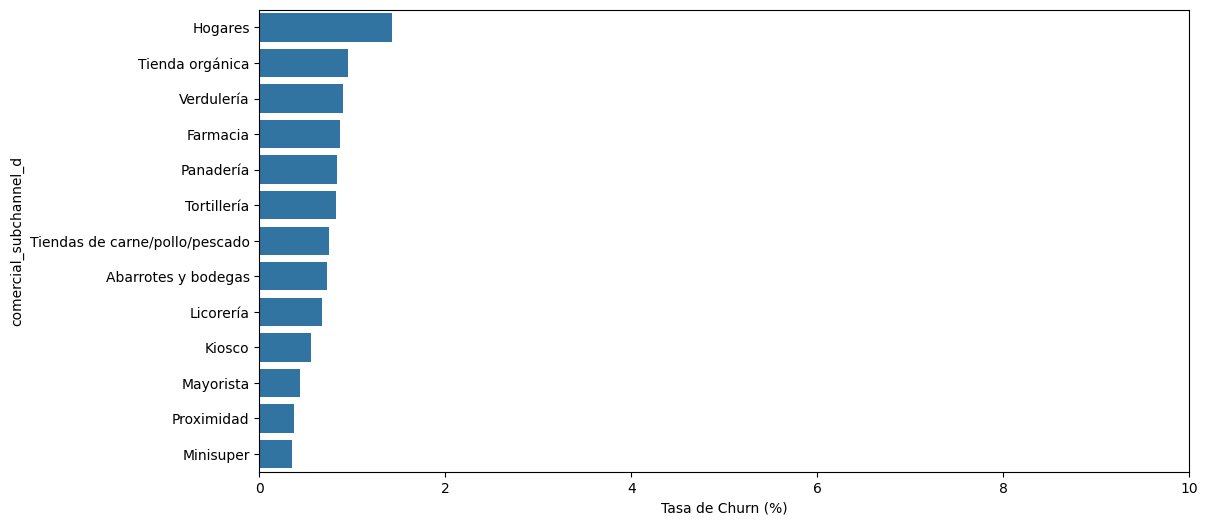

In [ ]:
subchannel_churn = (
    final_merge
    .groupby("comercial_subchannel_d")["target"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=subchannel_churn.values,
    y=subchannel_churn.index
)

plt.xlabel("Tasa de Churn (%)")
plt.xlim(0,10)

In [ ]:
perdidos = (
    final_merge
    .groupby("comercial_subchannel_d")["target"]
    .sum()
    .sort_values(ascending=False)
)

<Axes: ylabel='comercial_subchannel_d'>

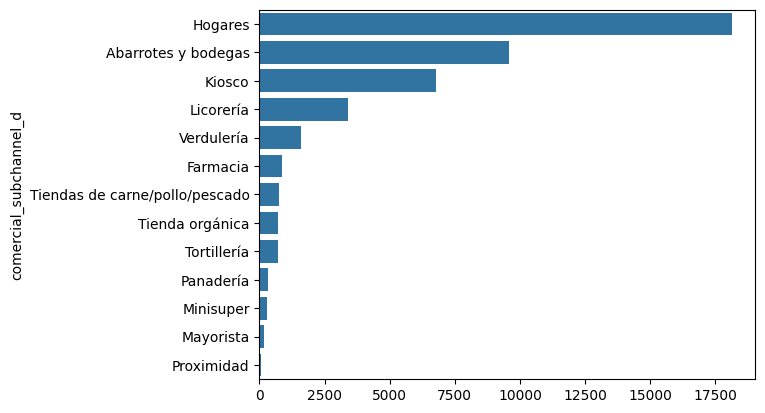

In [ ]:
sns.barplot(
    x=perdidos.values,
    y=perdidos.index
)

In [ ]:
pivot = pd.pivot_table(
    final_merge,
    values="target",
    index="comercial_subchannel_d",
    columns="rtm_customer_size_d",
    aggfunc="mean"
)

<Axes: xlabel='rtm_customer_size_d', ylabel='comercial_subchannel_d'>

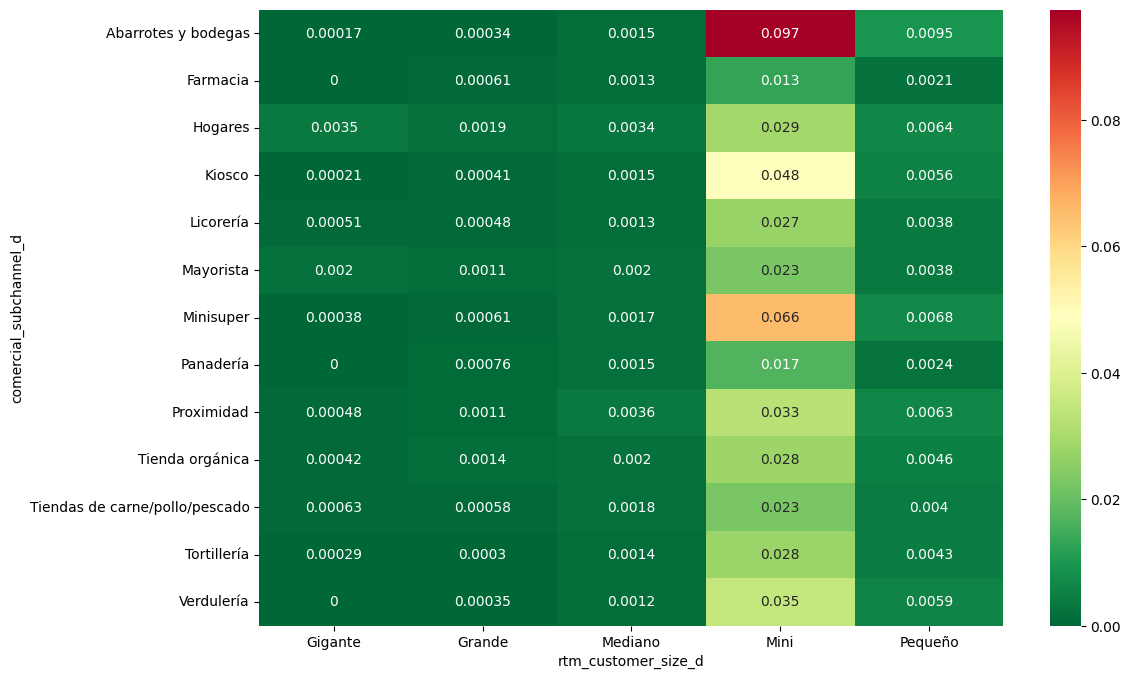

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    pivot,
    annot=True,
    cmap="RdYlGn_r"
)

In [ ]:
subchannel_coolers = (
    final_merge
    .groupby("comercial_subchannel_d")
    .agg({
        "num_coolers":"mean",
        "target":"mean"
    })
)

<Axes: xlabel='num_coolers', ylabel='target'>

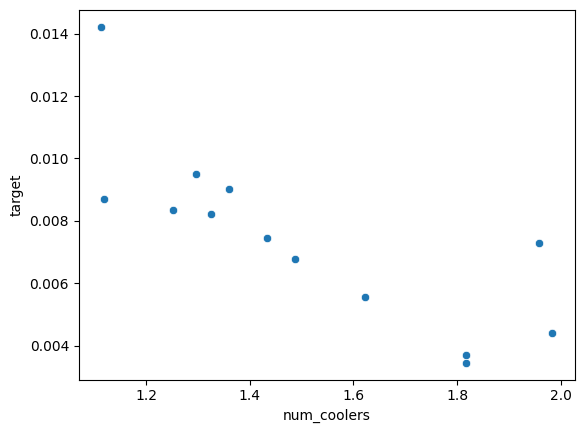

In [ ]:
sns.scatterplot(
    data=subchannel_coolers,
    x="num_coolers",
    y="target"
)

In [ ]:
ventas_subcanal = (
    final_merge
    .groupby("comercial_subchannel_d")
    .agg({
        "uni_boxes_sold_m":"mean",
        "target":"mean"
    })
)

<Axes: xlabel='uni_boxes_sold_m', ylabel='target'>

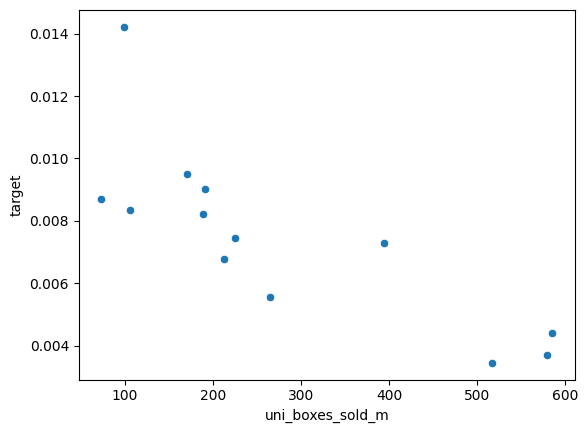

In [ ]:
sns.scatterplot(
    data=ventas_subcanal,
    x="uni_boxes_sold_m",
    y="target"
)

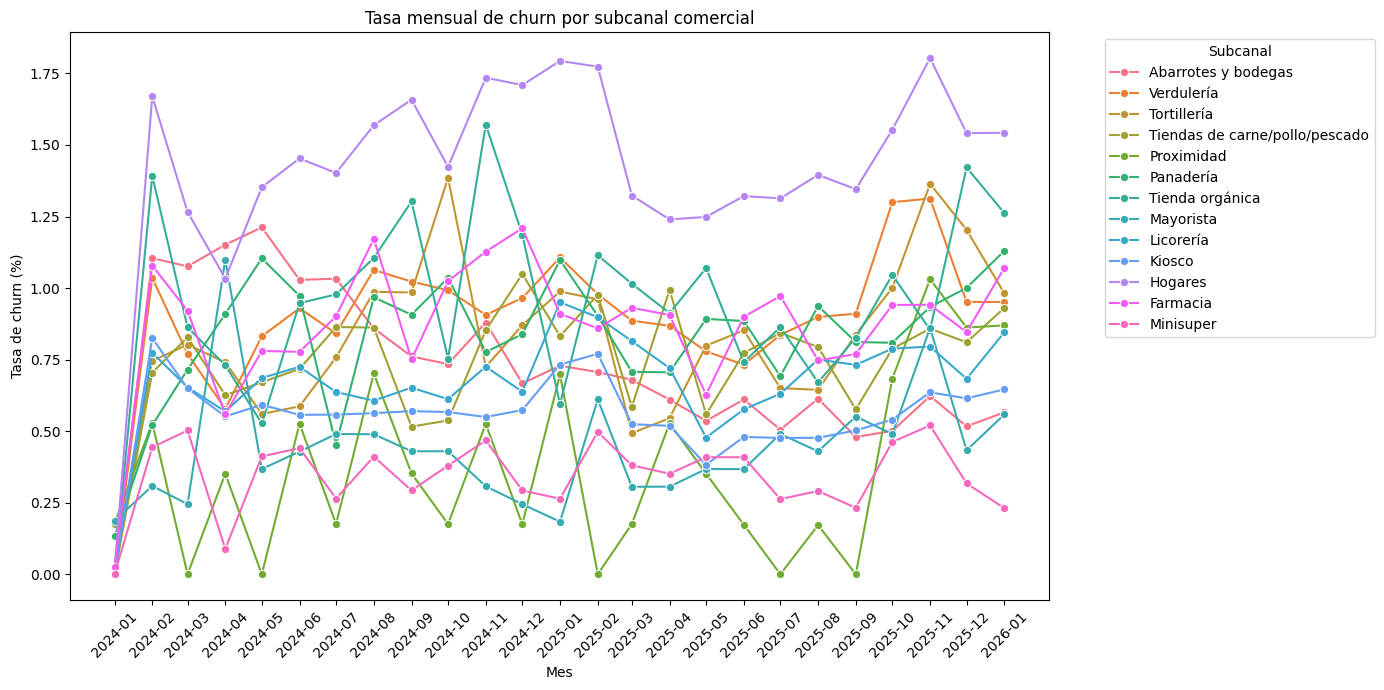

In [ ]:
final_merge["calmonth_dt"] = pd.to_datetime(
    final_merge["calmonth"].astype(str),
    format="%Y%m"
)

# 2. Tasa de churn por mes y subcanal
churn_mes = (
    final_merge
    .groupby(["calmonth_dt", "comercial_subchannel_d"])["target"]
    .mean()
    .mul(100)
    .reset_index()
)

# 3. Ordenar meses
churn_mes = churn_mes.sort_values("calmonth_dt")

# 4. Gráfica temporal corregida
plt.figure(figsize=(14,7))

sns.lineplot(
    data=churn_mes,
    x="calmonth_dt",
    y="target",
    hue="comercial_subchannel_d",
    marker="o"
)

plt.title("Tasa mensual de churn por subcanal comercial")
plt.xlabel("Mes")
plt.ylabel("Tasa de churn (%)")
plt.xticks(
    churn_mes["calmonth_dt"].drop_duplicates(),
    churn_mes["calmonth_dt"].dt.strftime("%Y-%m").drop_duplicates(),
    rotation=45
)
plt.legend(title="Subcanal", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## COOLERS

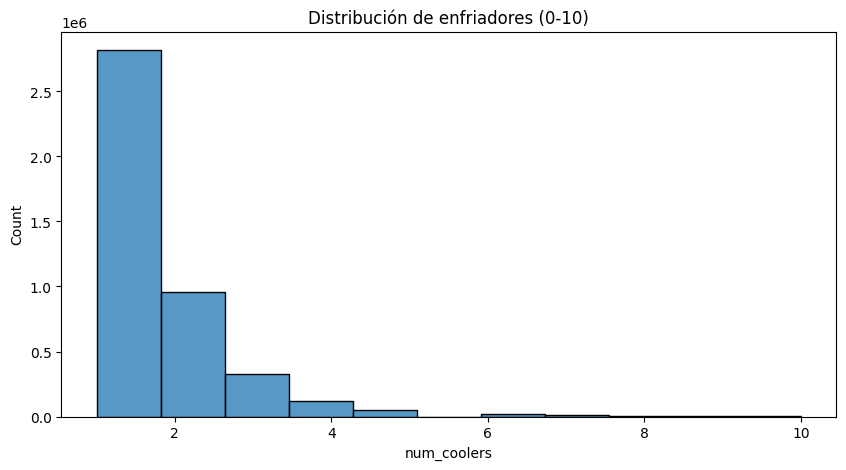

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    final_merge.loc[
        final_merge["num_coolers"] <= 10,
        "num_coolers"
    ],
    bins=11
)

plt.title("Distribución de enfriadores (0-10)")
plt.show()

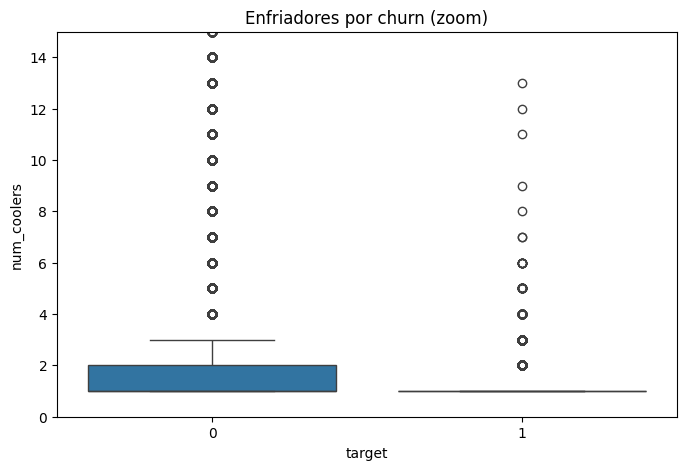

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=final_merge,
    x="target",
    y="num_coolers"
)

plt.ylim(0,15)

plt.title("Enfriadores por churn (zoom)")
plt.show()

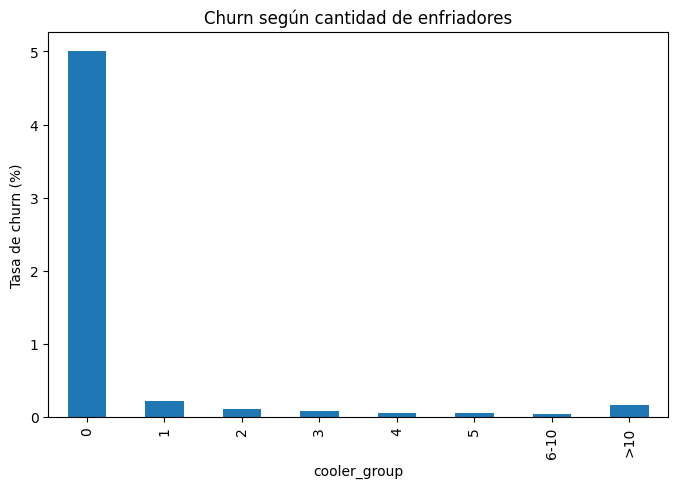

In [ ]:
final_merge['cooler_group'] = pd.cut(
    final_merge['num_coolers'].fillna(0),
    bins=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 10.5, np.inf],
    labels=['0', '1', '2', '3', '4', '5', '6-10', '>10'],
    right=True
).astype(str)

cooler_churn = (
    final_merge
    .groupby("cooler_group")["target"]
    .mean()
    .mul(100)
)

cooler_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("Tasa de churn (%)")
plt.title("Churn según cantidad de enfriadores")
plt.show()

In [ ]:
# Si no lo tienes instalado:
# !pip install lightgbm

import pandas as pd
import numpy as np
import lightgbm as lgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder

# =========================
# 1. Preparar datos
# =========================

df_model = final_merge.copy()

y = df_model["target"]
X = df_model.drop(columns=["target"])

# Quitar IDs y columnas de fecha que no son numéricas para el modelo
cols_to_drop = ["customer_id", "client_id", "Cliente", "cliente", "calmonth_dt"]

X = X.drop(columns=[col for col in cols_to_drop if col in X.columns])

# =========================
# 2. Codificar categóricas
# LightGBM puede trabajar bien con categorías codificadas
# =========================

cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns

for col in cat_cols:
    le = LabelEncoder()
    X[col] = X[col].astype(str)
    X[col] = le.fit_transform(X[col])

# =========================
# 3. Train / test split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# 4. Modelo LightGBM
# =========================

lgbm_model = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    class_weight="balanced",
    random_state=42
)

lgbm_model.fit(X_train, y_train)

# =========================
# 5. Evaluación
# =========================

y_pred = lgbm_model.predict(X_test)
y_proba = lgbm_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

[LightGBM] [Info] Number of positive: 34722, number of negative: 3990909
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.129132 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 646
[LightGBM] [Info] Number of data points in the train set: 4025631, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    997727
           1       0.72      1.00      0.84      8681

    accuracy                           1.00   1006408
   macro avg       0.86      1.00      0.92   1006408
weighted avg       1.00      1.00      1.00   1006408

ROC AUC: 0.9991277411201092


In [ ]:
# =========================
# 6. Importancia de variables
# =========================

feature_importance = pd.DataFrame({
    "variable": X.columns,
    "importance": lgbm_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance.head()

,variable,importance
5,territory_d,4865
0,calmonth,3235
6,comercial_subchannel_d,2137
7,rtm_customer_size_d,1301
1,num_transacciones,1239


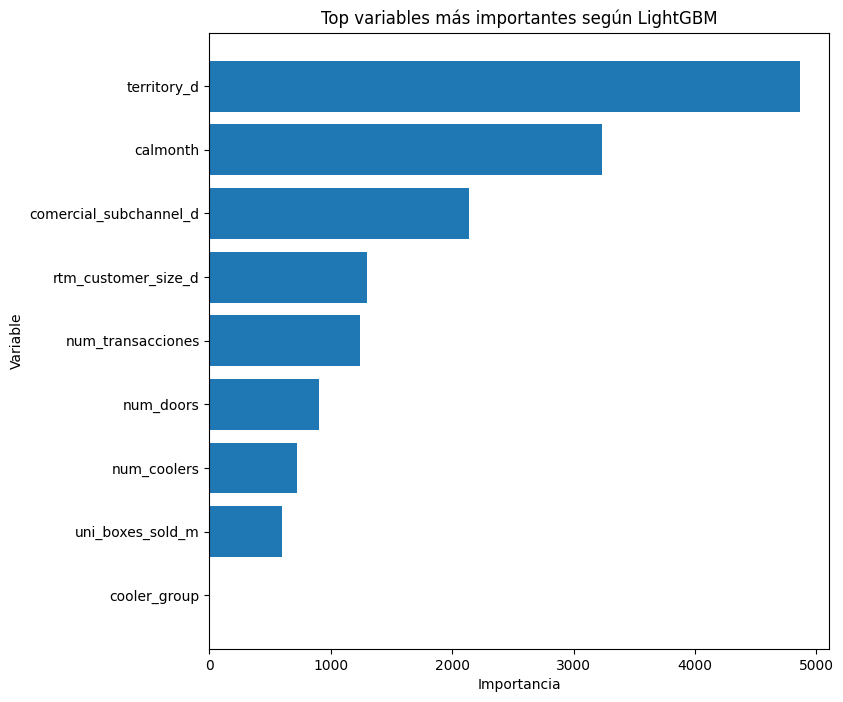

In [ ]:
import matplotlib.pyplot as plt

top_n = 25

plt.figure(figsize=(8, 8))
plt.barh(
    feature_importance.head(top_n)["variable"][::-1],
    feature_importance.head(top_n)["importance"][::-1]
)
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Top variables más importantes según LightGBM")
plt.show()

In [ ]:
# Seleccionar variables con importancia mayor a 0
selected_features_lgbm = feature_importance[
    feature_importance["importance"] > 0
]["variable"].tolist()

print("Número de variables seleccionadas:", len(selected_features_lgbm))
selected_features_lgbm

Número de variables seleccionadas: 9


['territory_d',
 'calmonth',
 'comercial_subchannel_d',
 'rtm_customer_size_d',
 'num_transacciones',
 'num_doors',
 'num_coolers',
 'uni_boxes_sold_m',
 'cooler_group']